In [3]:
print("Hello Notebook")

Hello Notebook


In [4]:
import os
print(os.getcwd())



c:\Users\acer\Desktop\PlantDocBot\notebooks


In [5]:
print(os.listdir(".."))

['data', 'eda.py', 'models', 'notebooks', 'processed', 'test.py', 'venv']


In [6]:
print(os.listdir("../data/raw"))

['plantvillage dataset']


In [7]:
DATASET_PATH = "../data/raw/plantvillage dataset/color"

In [8]:
import os
print(os.getcwd())

c:\Users\acer\Desktop\PlantDocBot\notebooks


In [9]:
import os

DATASET_PATH = "../data/raw/plantvillage dataset/color"

print("Path exists:", os.path.exists(DATASET_PATH))

disease_names = []
image_counts = []

for disease in os.listdir(DATASET_PATH):
    disease_path = os.path.join(DATASET_PATH, disease)
    
    if os.path.isdir(disease_path):
        num_images = len(os.listdir(disease_path))
        disease_names.append(disease)
        image_counts.append(num_images)

print("Total classes:", len(disease_names))

Path exists: True
Total classes: 38


In [11]:
import pandas as pd

df = pd.DataFrame({
    "Disease Name": disease_names,
    "Number of Images": image_counts
})

df

,Disease Name,Number of Images
0,Apple___Apple_scab,630
1,Apple___Black_rot,621
2,Apple___Cedar_apple_rust,275
3,Apple___healthy,1645
4,Blueberry___healthy,1502
5,Cherry_(including_sour)___healthy,854
6,Cherry_(including_sour)___Powdery_mildew,1052
7,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,513
8,Corn_(maize)___Common_rust_,1192
9,Corn_(maize)___healthy,1162


In [12]:
# ================================
# EDA – Dataset Loading & Counts
# ================================

from torchvision.datasets import ImageFolder
from collections import Counter
import os

# ✅ FIXED PATH
data_dir = "../data/raw/plantvillage dataset/grayscale"

# Optional: check path first
print("Path exists:", os.path.exists(data_dir))

dataset = ImageFolder(root=data_dir)

labels = [label for _, label in dataset.samples]
class_counts = Counter(labels)

disease_names = dataset.classes
image_counts = [class_counts[i] for i in range(len(disease_names))]

print("EDA variables recreated successfully")
print("Total Classes:", len(disease_names))

Path exists: True
EDA variables recreated successfully
Total Classes: 38


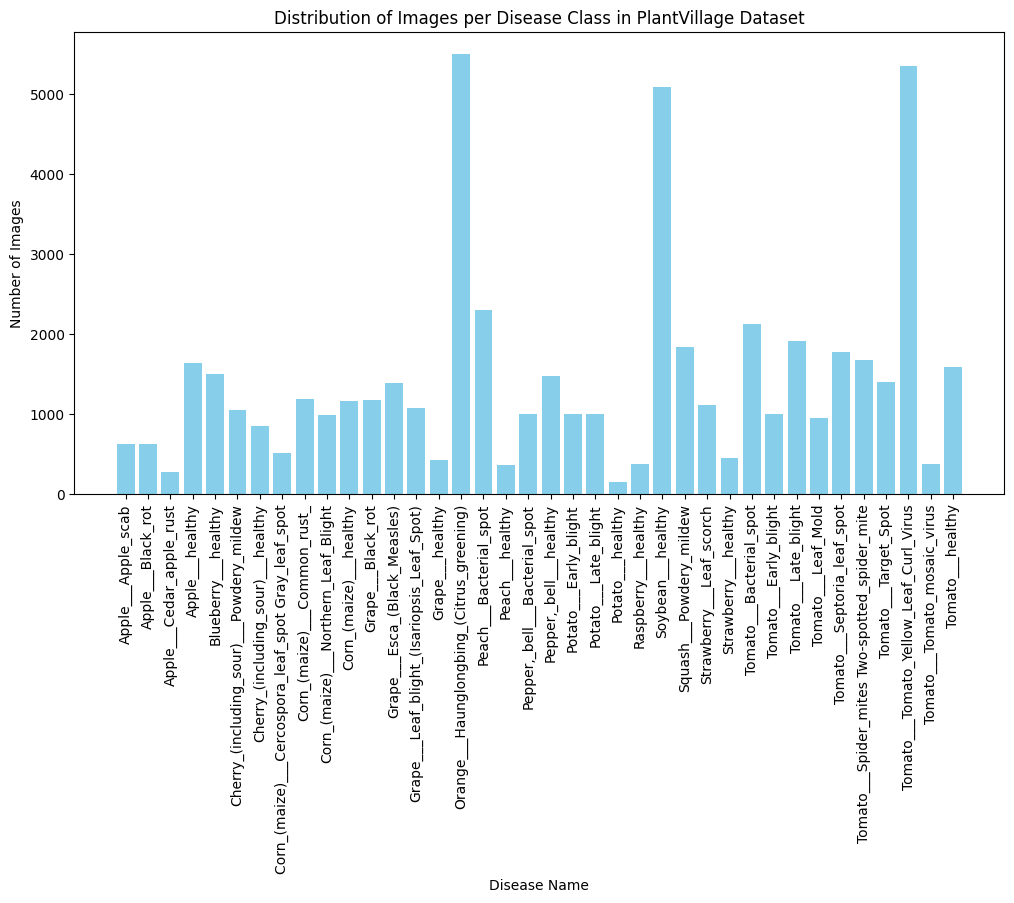

In [13]:
import matplotlib.pyplot as plt

# Create a bar chart
plt.figure(figsize=(12,6))
plt.bar(disease_names, image_counts, color='skyblue')
plt.xticks(rotation=90)  # Rotate x labels for readability
plt.xlabel("Disease Name")
plt.ylabel("Number of Images")
plt.title("Distribution of Images per Disease Class in PlantVillage Dataset")
plt.show()

In [14]:
# Step 2: Data Augmentation and Transforms
import torch
import torchvision

print("Torch:", torch.__version__)
print("Torchvision:", torchvision.__version__)


Torch: 2.10.0+cpu
Torchvision: 0.25.0+cpu


In [15]:
from torchvision import transforms

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Transforms Ready!")

Transforms Ready!


In [16]:
from torchvision.datasets import ImageFolder

data_dir = "../data/raw/plantvillage dataset/grayscale"

full_dataset = ImageFolder(
    root=data_dir,
    transform=train_transforms
)

print("Dataset Loaded Successfully!")
print("Total Images:", len(full_dataset))

Dataset Loaded Successfully!
Total Images: 54305


In [17]:
from torch.utils.data import random_split

# Total dataset size
total_size = len(full_dataset)

# 80% training, 20% validation
train_size = int(0.8 * total_size)
val_size = total_size - train_size

# Split
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

print("Training Images:", len(train_dataset))
print("Validation Images:", len(val_dataset))

Training Images: 43444
Validation Images: 10861


In [18]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

print("Train Loader Ready!")
print("Val Loader Ready!")

Train Loader Ready!
Val Loader Ready!


In [19]:
import torch
from collections import Counter

labels = [label for _, label in full_dataset.samples]
class_counts = Counter(labels)

class_weights = 1.0 / torch.tensor(list(class_counts.values()), dtype=torch.float)

print("Class Weights:", class_weights)

Class Weights: tensor([0.0016, 0.0016, 0.0036, 0.0006, 0.0007, 0.0010, 0.0012, 0.0019, 0.0008,
        0.0010, 0.0009, 0.0008, 0.0007, 0.0009, 0.0024, 0.0002, 0.0004, 0.0028,
        0.0010, 0.0007, 0.0010, 0.0010, 0.0066, 0.0027, 0.0002, 0.0005, 0.0009,
        0.0022, 0.0005, 0.0010, 0.0005, 0.0011, 0.0006, 0.0006, 0.0007, 0.0002,
        0.0027, 0.0006])
